### Optical Flow Model


In [1]:
# All libraries used for the project (Optical Flow)
import pandas as pd
import numpy as np 
import seaborn as sns 
import re
import xarray as xr
import cartopy.crs as ccrs  # CRS stands for "coordinate reference system"
import matplotlib.pyplot as plt
import ocf_blosc2
import cv2
from skimage.metrics import structural_similarity as ssim

plt.rcParams["figure.figsize"] = (20, 12)

/Users/nataliaefremova/miniforge3/envs/tf/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# Path to the file where data is stored
SATELLITE_ZARR_PATH = "gs://public-datasets-eumetsat-solar-forecasting/satellite/EUMETSAT/SEVIRI_RSS/v4/2023_hrv.zarr" 

In [3]:
# Opening dataset
dataset = xr.open_dataset(
    SATELLITE_ZARR_PATH, 
    engine="zarr", 
    chunks="auto",  # Load the data as a dask array
)

GroupNotFoundError: No group found in store 'gs://public-datasets-eumetsat-solar-forecasting/satellite/EUMETSAT/SEVIRI_RSS/v4/2023_hrv.zarr' at path ''

In [ ]:
# Plotting for a specific time (10th August 2023 11:50am)
DATETIME_TO_PLOT = "2023-08-10 11:50"
data_array = dataset['data']
data_array.sel(time=DATETIME_TO_PLOT).plot();

In [ ]:
# Sorting data by time
data_array = data_array.sortby('time')

# Checking for any duplicates & removing them
_, unique_index = np.unique(data_array['time'], return_index=True)
data_array = data_array.isel(time=unique_index)

# Slicing & selecting for specifc time & coordinates 
# saved into a subset
subset = (
    data_array
    .sel(time=slice("2023-08-10 12:00", "2023-08-10 12:10"))
    .isel(
        x_geostationary=slice(1000, 1200), # x-axis
        y_geostationary=slice(1400, 1600), # y-axis
    )
)

print(subset)


In [ ]:
# Adding coast lines for the same time & date
ax = plt.axes(projection=ccrs.Geostationary(central_longitude=9.5))
data_array.sel(time=DATETIME_TO_PLOT, variable='HRV').plot.pcolormesh(
    ax=ax, 
    transform=ccrs.Geostationary(central_longitude=9.5), 
    x="x_geostationary", 
    y="y_geostationary",
    add_colorbar=False,
)
ax.coastlines();

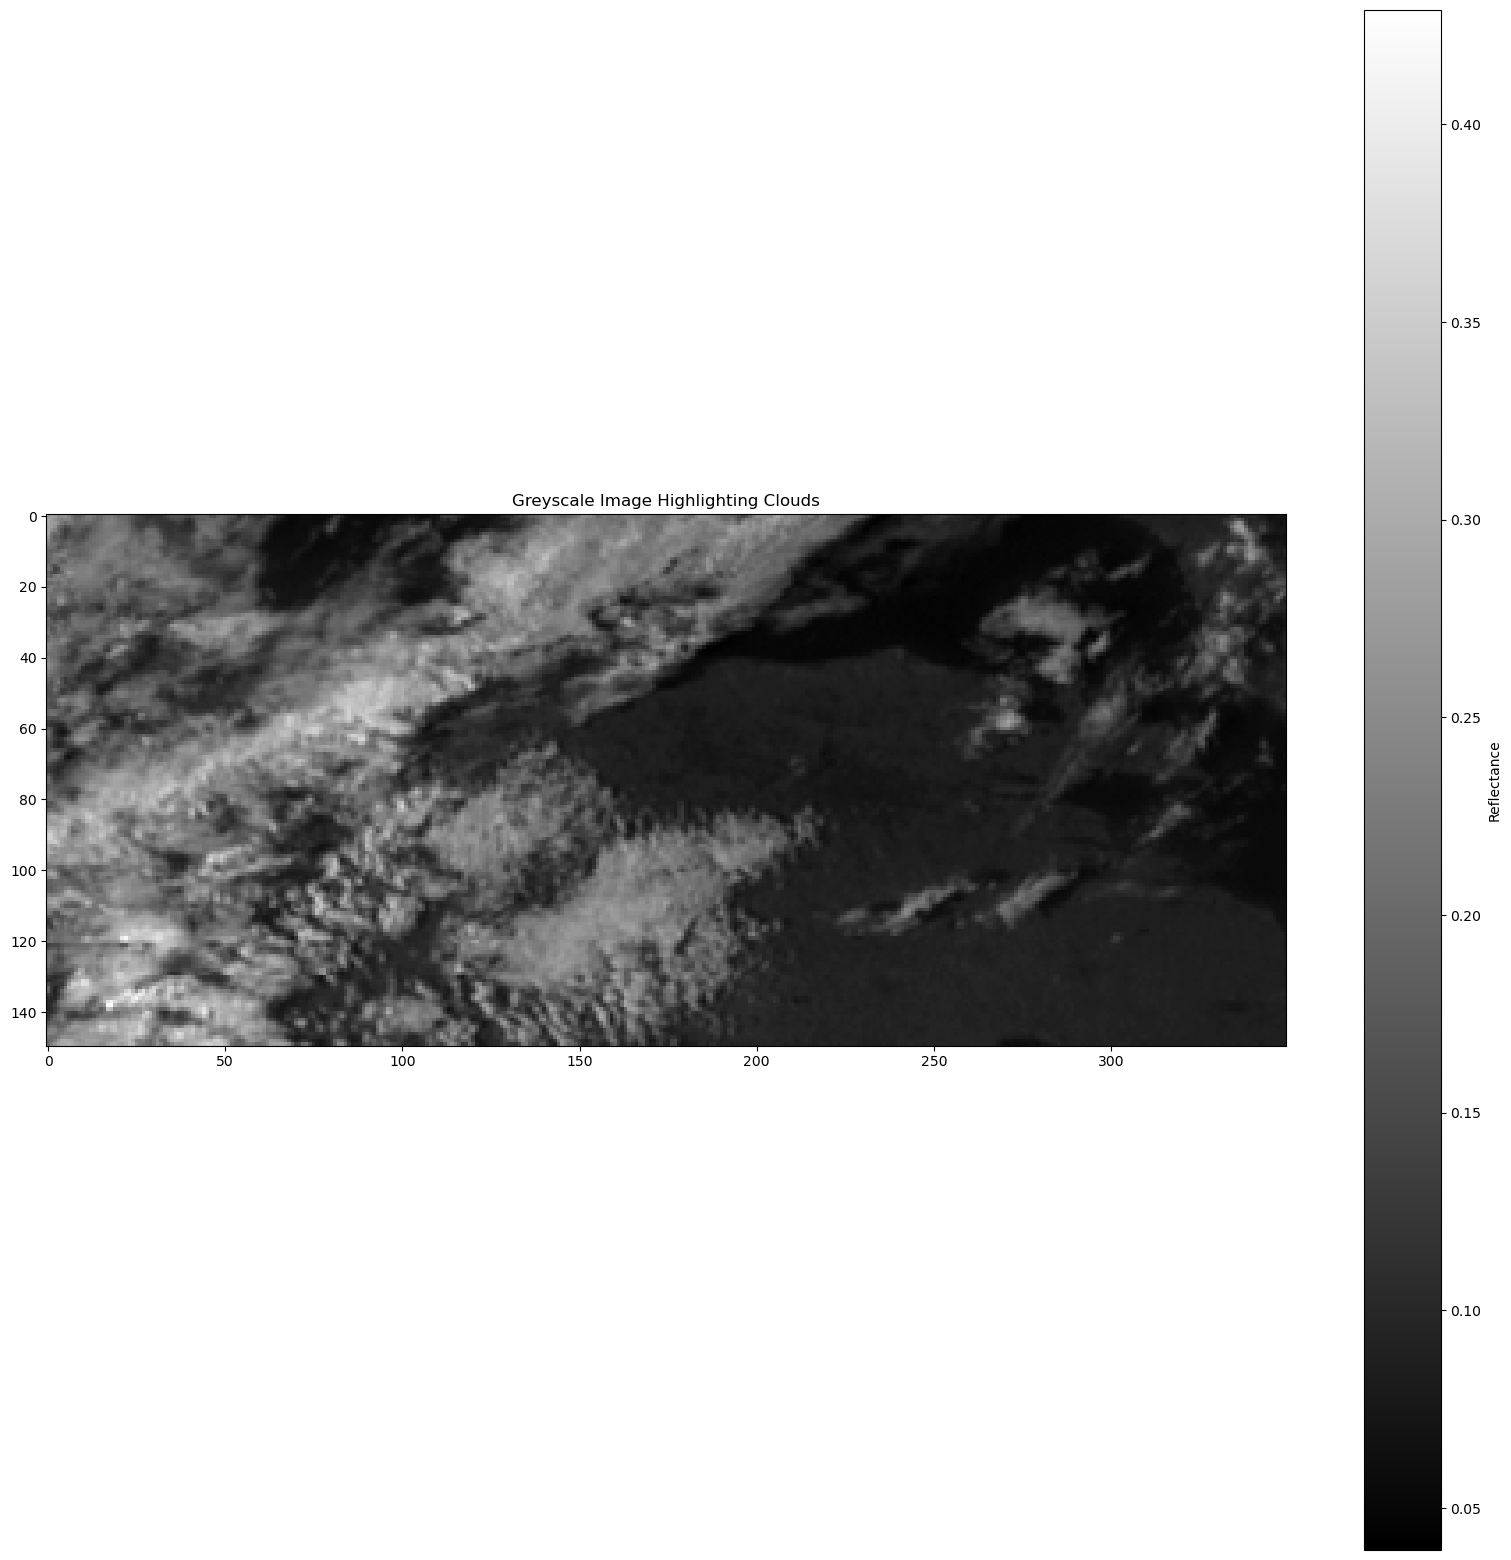

In [7]:
# Greyscale the image
time_to_plot = "2023-08-10T16:40:00"
time_selected = dataset.sel(time=time_to_plot)

# Selecting South of England
x_start, x_end = 1850, 2200  
y_start, y_end = 3150, 3300  

spatial_subset = time_selected.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
data_array = spatial_subset['data'].squeeze('variable', drop=True)

# Plotting greyscale image
plt.figure(figsize=(20, 20))
plt.imshow(data_array, cmap='gray')
plt.colorbar(label='Reflectance')
plt.title('Greyscale Image Highlighting Clouds')
plt.show()


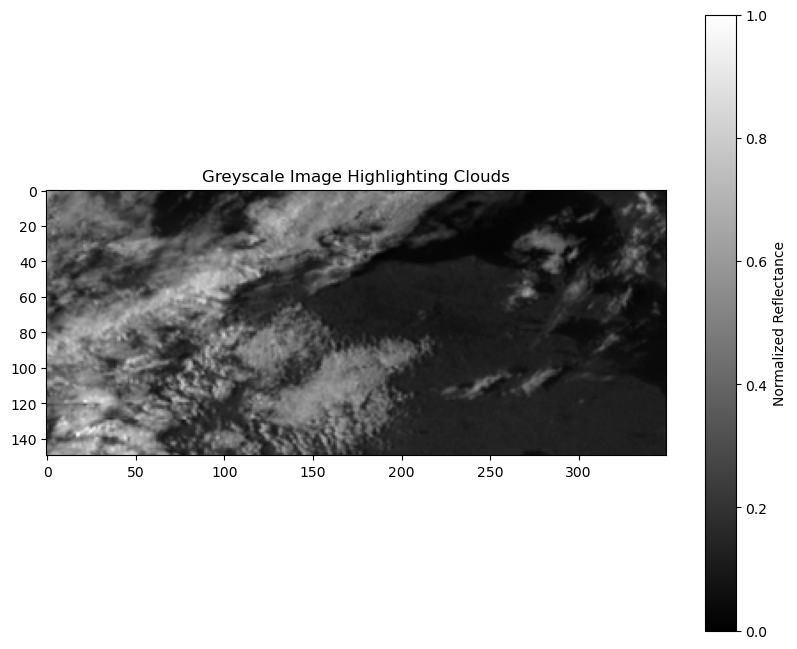

In [8]:
# Normalization and greyscale
time_to_plot = "2023-08-10T16:40:00"
time_selected = dataset.sel(time=time_to_plot)

# South of England
x_start, x_end = 1850, 2200  
y_start, y_end = 3150, 3300  

spatial_subset = time_selected.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
data_array = spatial_subset['data'].squeeze('variable', drop=True)

# Normalization
normalized_data = (data_array - data_array.min()) / (data_array.max() - data_array.min())

# Greyscale image
plt.figure(figsize=(10, 8))
plt.imshow(normalized_data, cmap='gray', vmin=0, vmax=1)
plt.colorbar(label='Normalized Reflectance')
plt.title('Greyscale Image Highlighting Clouds')
plt.show()



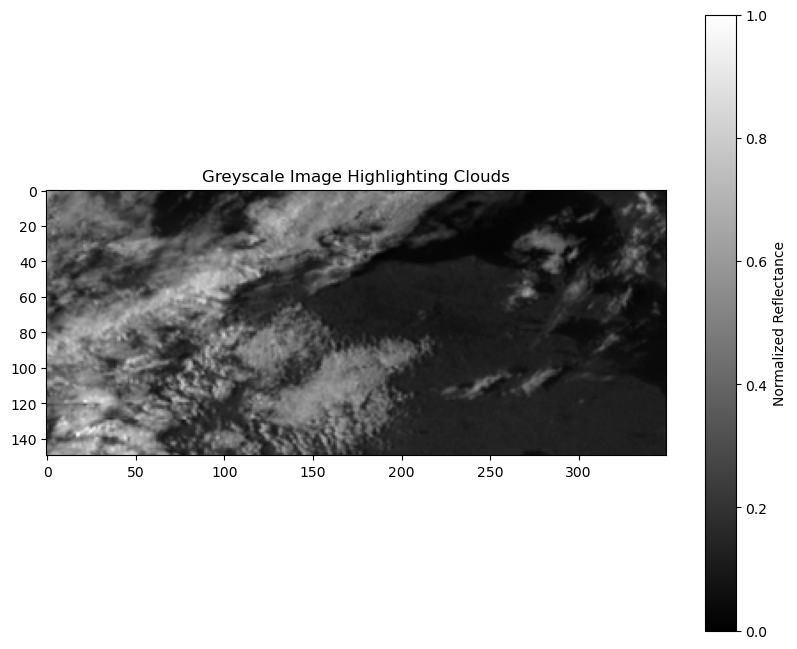

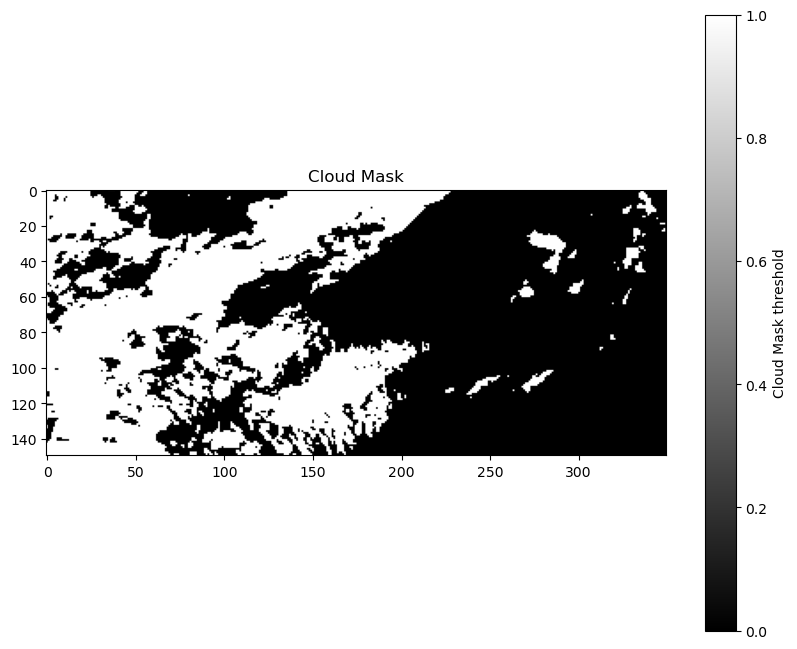

In [9]:
# Cloud mask (10th August 2023 16:40) 
time_to_plot = "2023-08-10T16:40:00"
time_selected = dataset.sel(time=time_to_plot)

# South of england
x_start, x_end = 1850, 2200  
y_start, y_end = 3150, 3300  

spatial_subset = time_selected.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
data_array = spatial_subset['data'].squeeze('variable', drop=True)

# Normalization
normalized_data = (data_array - data_array.min()) / (data_array.max() - data_array.min())

# Greyscale image
plt.figure(figsize=(10, 8))
plt.imshow(normalized_data, cmap='gray', vmin=0, vmax=1)
plt.colorbar(label='Normalized Reflectance')
plt.title('Greyscale Image Highlighting Clouds')
plt.show()

#  Mask for clouds
threshold = 0.3  
cloud_mask = normalized_data > threshold

# Cloud mask
plt.figure(figsize=(10, 8))
plt.imshow(cloud_mask, cmap='gray')
plt.colorbar(label='Cloud Mask threshold')
plt.title('Cloud Mask')
plt.show()


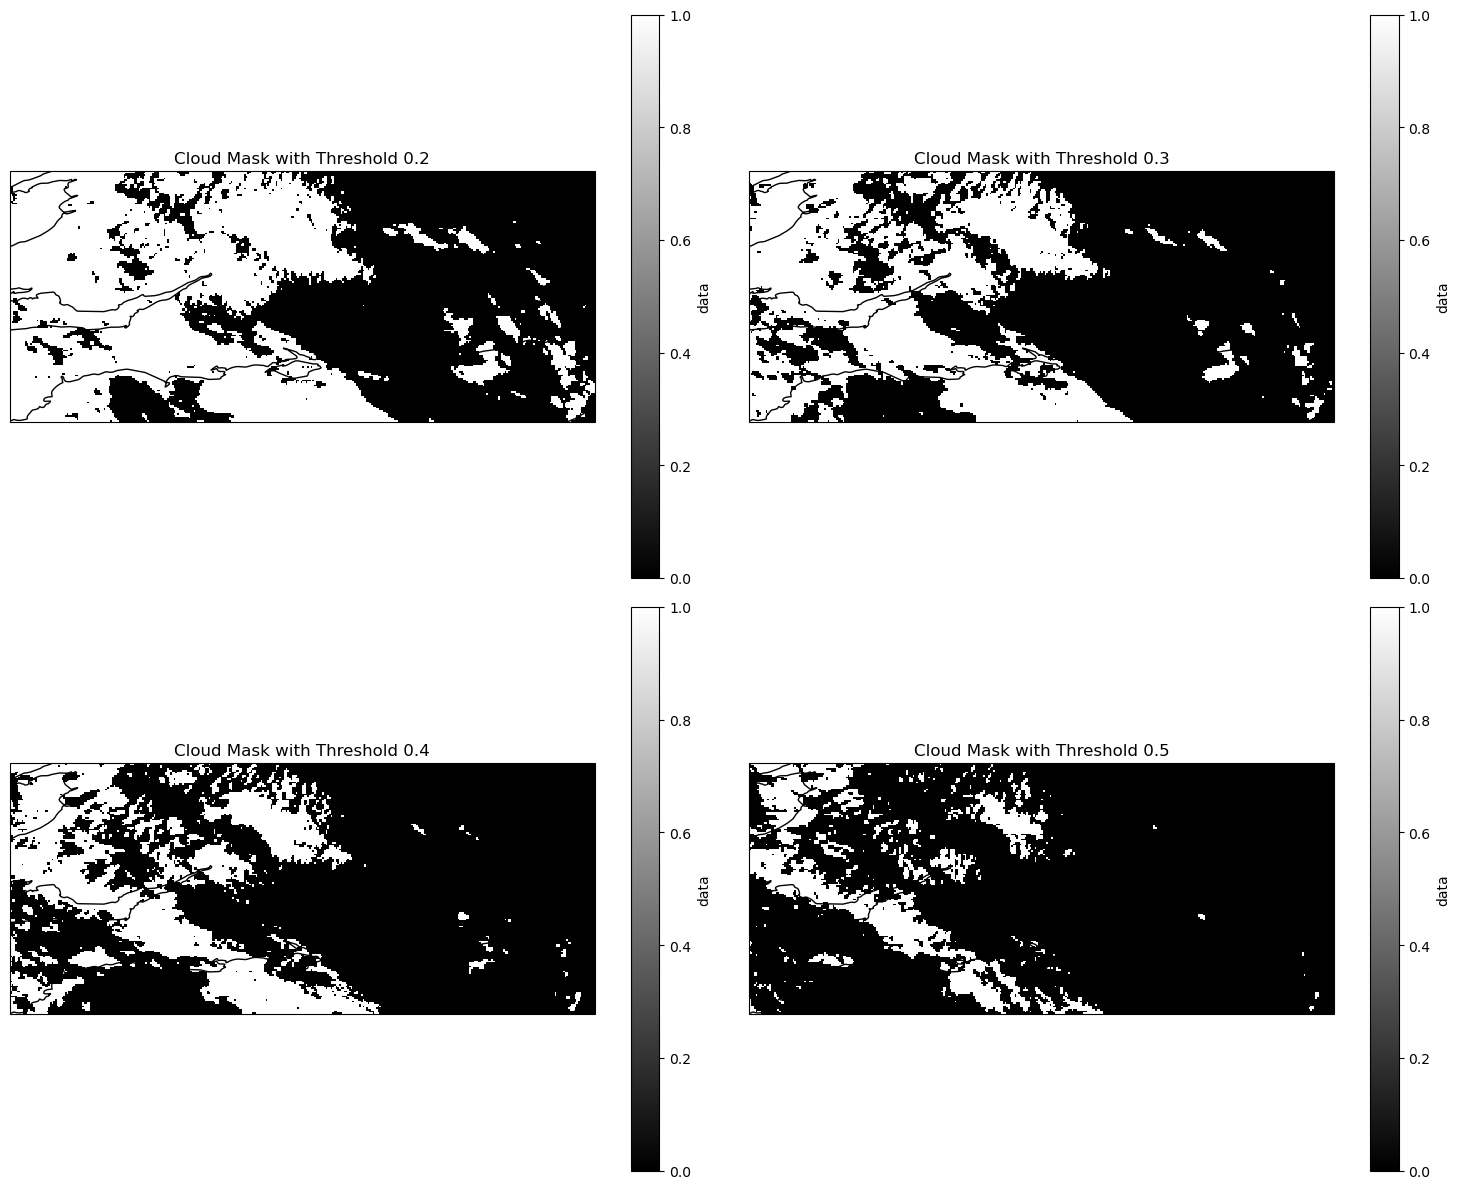

In [10]:
time_to_plot = "2023-08-10T16:40:00"
time_selected = dataset.sel(time=time_to_plot)

# South of england
x_start, x_end = 1850, 2200  
y_start, y_end = 3150, 3300  

spatial_subset = time_selected.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
data_array = spatial_subset['data'].squeeze('variable', drop=True)

# Normalization
normalized_data = (data_array - data_array.min()) / (data_array.max() - data_array.min())

# Different thresholds
thresholds = [0.2, 0.3, 0.4, 0.5]

# Plotting sub-plots
fig, axs = plt.subplots(2, 2, figsize=(15, 12), subplot_kw={'projection': ccrs.Geostationary(central_longitude=9.5)})

for ax, threshold in zip(axs.flatten(), thresholds):
    # Applying various threshold
    cloud_mask = normalized_data > threshold
    
    # Cloud masks
    cloud_mask.plot.pcolormesh(
        ax=ax, 
        transform=ccrs.Geostationary(central_longitude=9.5), 
        x="x_geostationary", 
        y="y_geostationary",
        cmap='gray',
        add_colorbar=True
    )
    ax.coastlines()
    ax.set_title(f'Cloud Mask with Threshold {threshold}')

plt.tight_layout()
plt.show()


### Optical Flow Model 1 (10th August 2023, Time 11:50 - 12:10)

image1 type: <class 'numpy.ndarray'>, dtype: uint8, shape: (150, 350)
image2 type: <class 'numpy.ndarray'>, dtype: uint8, shape: (150, 350)
image3 type: <class 'numpy.ndarray'>, dtype: uint8, shape: (150, 350)


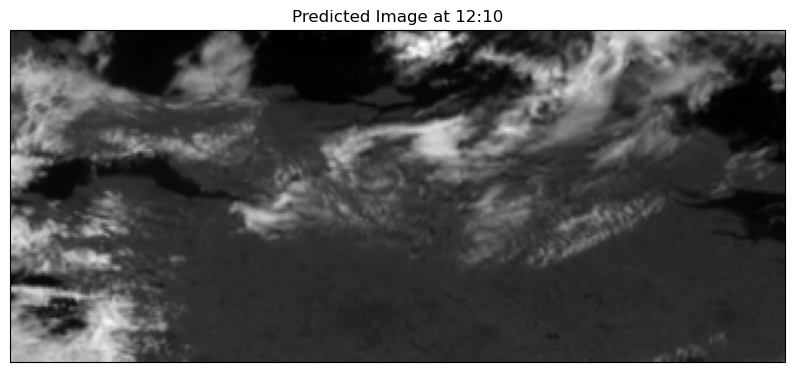

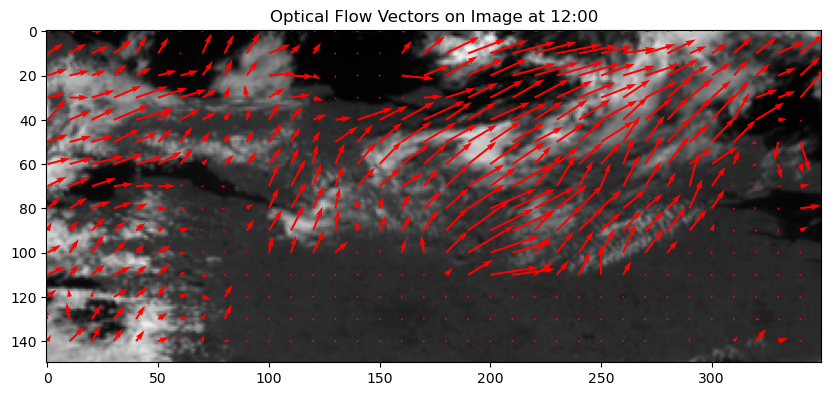

In [11]:
# Time points
time1 = "2023-08-10T11:50:00"
time2 = "2023-08-10T12:00:00"
time3 = "2023-08-10T12:10:00"  # Time to predict

# Data sets for those specific times
data1 = dataset.sel(time=time1)
data2 = dataset.sel(time=time2)
data3 = dataset.sel(time=time3)

# South of England
x_start, x_end = 1850, 2200  
y_start, y_end = 3150, 3300  

# Subsets
subset1 = data1.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
subset2 = data2.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
subset3 = data3.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))

data_array1 = subset1['data'].squeeze('variable', drop=True)
data_array2 = subset2['data'].squeeze('variable', drop=True)
data_array3 = subset3['data'].squeeze('variable', drop=True)

# Normalization
norm_data1 = (data_array1 - data_array1.min()) / (data_array1.max() - data_array1.min())
norm_data2 = (data_array2 - data_array2.min()) / (data_array2.max() - data_array2.min())
norm_data3 = (data_array3 - data_array3.min()) / (data_array3.max() - data_array3.min())

# Converting to 'Uint8' data type
image1 = (norm_data1 * 255).astype(np.uint8).values
image2 = (norm_data2 * 255).astype(np.uint8).values
image3 = (norm_data3 * 255).astype(np.uint8).values

# Checking for types and shapes
print(f'image1 type: {type(image1)}, dtype: {image1.dtype}, shape: {image1.shape}')
print(f'image2 type: {type(image2)}, dtype: {image2.dtype}, shape: {image2.shape}')
print(f'image3 type: {type(image3)}, dtype: {image3.dtype}, shape: {image3.shape}')

# Dense optical flow using the Farnebacks method
flow = cv2.calcOpticalFlowFarneback(image1, image2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

# Extracting flow components
u = flow[..., 0] # Horizontal flow
v = flow[..., 1] # Vertical flow

# Predicting the next image using the optical flow vectors
def predict_next_image(current_image, u, v):
    height, width = current_image.shape
    predicted_image = np.zeros_like(current_image)

    # Creating a grid of coordinates
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Calculating new positions
    new_x = (x_coords + u).astype(np.float32)
    new_y = (y_coords + v).astype(np.float32)

    # Using cv2.remap to apply the flow to the image
    predicted_image = cv2.remap(current_image, new_x, new_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    return predicted_image

# Predict 12:10 image
predicted_image_1210 = predict_next_image(image2, u, v)

# Visualizing predicted image (12:10)
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.Geostationary(central_longitude=0)})
ax.imshow(predicted_image_1210, cmap='gray', extent=(x_start, x_end, y_start, y_end), transform=ccrs.Geostationary(central_longitude=0))
ax.coastlines()
ax.set_title('Predicted Image at 12:10')
plt.show()

# Visualizing optical flow vectors (on 11:50)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image2, cmap='gray')
ax.quiver(np.arange(0, u.shape[1], 10), np.arange(0, v.shape[0], 10), u[::10, ::10], v[::10, ::10], color='r')
ax.set_title('Optical Flow Vectors on Image at 12:00')
plt.show()


### Optical Flow Model 2 (Final) (10th August 2023, Time 16:40 - 17:00)

image1 type: <class 'numpy.ndarray'>, dtype: uint8, shape: (80, 80)
image2 type: <class 'numpy.ndarray'>, dtype: uint8, shape: (80, 80)
image3 type: <class 'numpy.ndarray'>, dtype: uint8, shape: (80, 80)


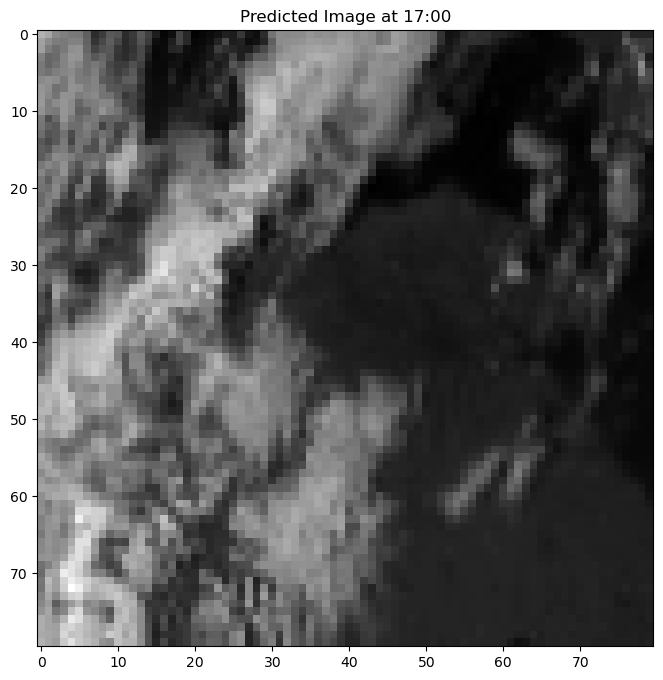

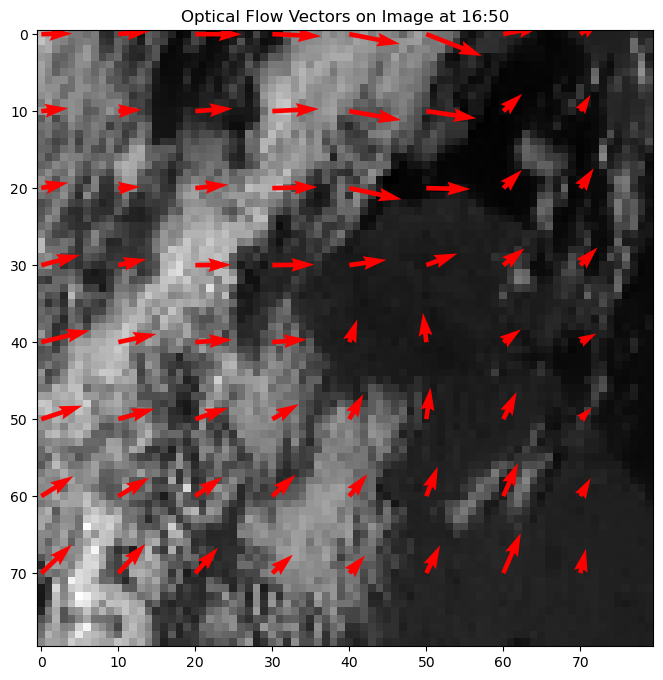

SSIM between predicted and actual image at 17:00: 0.31296223411284896


In [12]:
# Time points
time1 = "2023-08-10T16:40:00"
time2 = "2023-08-10T16:50:00"
time3 = "2023-08-10T17:00:00"  # Time to predict

data1 = dataset.sel(time=time1)
data2 = dataset.sel(time=time2)
data3 = dataset.sel(time=time3)

x_start, x_end = 1850, 2200  
y_start, y_end = 3150, 3300  

subset1 = data1.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
subset2 = data2.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))
subset3 = data3.isel(x_geostationary=slice(x_start, x_end), y_geostationary=slice(y_start, y_end))

data_array1 = subset1['data'].squeeze('variable', drop=True)
data_array2 = subset2['data'].squeeze('variable', drop=True)
data_array3 = subset3['data'].squeeze('variable', drop=True)

def normalize(data_array):
    return (data_array - data_array.min()) / (data_array.max() - data_array.min())

norm_data1 = normalize(data_array1)
norm_data2 = normalize(data_array2)
norm_data3 = normalize(data_array3)

# Downscalling to 80x80
def convert_and_resize(norm_data):
    image = (norm_data * 255).astype(np.uint8).values
    resized_image = cv2.resize(image, (80, 80), interpolation=cv2.INTER_LINEAR)
    return resized_image

image1 = convert_and_resize(norm_data1)
image2 = convert_and_resize(norm_data2)
image3 = convert_and_resize(norm_data3)

# Applying histogram equalization and Gaussian blurring
def preprocess_image(image):
    # Histogram equalization
    equalized = cv2.equalizeHist(image)
    
    # Gaussian blurring
    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)
    
    return blurred


# Checking for types and shapes
print(f'image1 type: {type(image1)}, dtype: {image1.dtype}, shape: {image1.shape}')
print(f'image2 type: {type(image2)}, dtype: {image2.dtype}, shape: {image2.shape}')
print(f'image3 type: {type(image3)}, dtype: {image3.dtype}, shape: {image3.shape}')

# Dense optical flow using the Farneback method

# Initial optical flow hyperparameters
# flow = cv2.calcOpticalFlowFarneback(image1, image2, None, 0.5, 3, 15, 3, 5, 1.2, 0)


# New Optical flow hyperparameters
flow = cv2.calcOpticalFlowFarneback(image1, image2, None,
                                    pyr_scale=0.3,  # Experimenting with different scales
                                    levels=5,       # more pyramid levels
                                    winsize=21,     # Increasing window size
                                    iterations=5,   # Increasing iterations for more precise flow estimation
                                    poly_n=7,       # Larger neighborhood size
                                    poly_sigma=1.5, # Increasing Gaussian standard deviation
                                    flags=0)


# Extracting flow components
u = flow[..., 0]  # Horizontal flow
v = flow[..., 1]  # Vertical flow

# Predicting the next image using the optical flow vectors
def predict_next_image(current_image, u, v):
    height, width = current_image.shape
    predicted_image = np.zeros_like(current_image)

    # Creating a grid of coordinates
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Calculating new positions
    new_x = (x_coords + u).astype(np.float32)
    new_y = (y_coords + v).astype(np.float32)

    # Using cv2.remap to apply the flow to the image
    predicted_image = cv2.remap(current_image, new_x, new_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    return predicted_image

# Predicting 17:00 image
predicted_image_1700 = predict_next_image(image2, u, v)

# Visualize=ing predicted image (12:10)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(predicted_image_1700, cmap='gray')
ax.set_title('Predicted Image at 17:00')
plt.show()

# Visualizing optical flow vectors (on 16:50)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image2, cmap='gray')
ax.quiver(np.arange(0, u.shape[1], 10), np.arange(0, v.shape[0], 10), u[::10, ::10], v[::10, ::10], color='r')
ax.set_title('Optical Flow Vectors on Image at 16:50')
plt.show()

# Computing SSIM between the predicted image and the actual image at 17:00
ssim_value = ssim(predicted_image_1700, image3, data_range=255)
print(f'SSIM between predicted and actual image at 17:00: {ssim_value}')
